# Campaign ROI Estimation: Exploratory Data Analysis

Load and inspect the raw campaign dataset.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Find the project root from the current Jupyter working directory.
# This works whether Jupyter starts in the project root or ml/notebooks.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = None

for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "data" / "raw" / "Campaign_ROI_Estimation_Dataset_150000.xlsx").exists():
        PROJECT_ROOT = candidate
        break

# Fallback for the current uploaded-file environment.
if PROJECT_ROOT is None:
    fallback_dataset = Path("/mnt/data/campaign_roi/Campaign_ROI_Estimation_Dataset_150000.xlsx")
    if fallback_dataset.exists():
        PROJECT_ROOT = fallback_dataset.parent.parent
        DATA_FILE = fallback_dataset
    else:
        raise FileNotFoundError(
            "Could not find Campaign_ROI_Estimation_Dataset_150000.xlsx. "
            "Make sure it is located in data/raw/."
        )

if "DATA_FILE" not in globals():
    DATA_FILE = (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "Campaign_ROI_Estimation_Dataset_150000.xlsx"
    )

SHEET_NAME = "Fact_CampaignPerformance"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_FILE)
print("Dataset exists:", DATA_FILE.exists())


Project root: C:\Users\Manas K. Bhoir\Desktop\campaign-roi-estimation
Dataset: C:\Users\Manas K. Bhoir\Desktop\campaign-roi-estimation\data\raw\Campaign_ROI_Estimation_Dataset_150000.xlsx
Dataset exists: True


In [2]:
df = pd.read_excel(
    DATA_FILE,
    sheet_name=SHEET_NAME
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.shape[1])


Dataset loaded successfully.
Shape: (150000, 40)
Columns: 40


In [3]:
df.head()

,CampaignID,CampaignDate,Platform,Region,Device,CustomerSegment,ProductCategory,CampaignType,Season,Budget,...,CampaignStatus,CampaignDurationDays,RepeatCustomers,NewCustomers,Orders,AverageOrderValue,DiscountPercent,RefundRate,MarketingObjective,CampaignSuccess
0,1,2023-08-17,Twitter (X),Europe,Smart TV,Premium,Education,Lead Generation,Spring,17380.32,...,Running,35,919,357,1276,281.78,17.68,8.09,Sales Growth,Excellent
1,2,2023-07-29,Google Ads,Middle East,Tablet,Enterprise,Automobile,Lead Generation,Summer,50909.19,...,Completed,36,12665,2287,14952,277.39,8.68,0.80,Sales Growth,Excellent
2,3,2024-03-05,Facebook,South America,Tablet,Returning,Travel,Retention,Holiday,336736.71,...,Completed,36,13464,1121,14585,369.98,0.96,3.15,Retention,Excellent
3,4,2023-10-20,YouTube,Asia Pacific,Desktop,Senior,Fashion,Seasonal Promotion,Festival,136115.68,...,Completed,61,9771,6139,15910,300.10,1.91,3.82,Sales Growth,Excellent
4,5,2024-11-27,Google Ads,Asia Pacific,Tablet,Returning,Electronics,Lead Generation,Festival,60218.33,...,Completed,76,2172,778,2950,486.51,27.55,5.99,Brand Awareness,Excellent


In [4]:
df.tail()

,CampaignID,CampaignDate,Platform,Region,Device,CustomerSegment,ProductCategory,CampaignType,Season,Budget,...,CampaignStatus,CampaignDurationDays,RepeatCustomers,NewCustomers,Orders,AverageOrderValue,DiscountPercent,RefundRate,MarketingObjective,CampaignSuccess
149995,149996,2023-12-20,Instagram,Asia Pacific,Smart TV,Senior,Travel,Lead Generation,Festival,136272.32,...,Completed,69,4817,7274,12091,297.73,29.90,6.65,Retention,Excellent
149996,149997,2024-08-10,Twitter (X),Europe,Smart TV,New,Healthcare,Lead Generation,Winter,481628.68,...,Running,55,3830,1756,5586,26.36,14.82,9.01,Brand Awareness,Poor
149997,149998,2023-11-02,Twitter (X),North America,Desktop,Returning,Electronics,Sales,Festival,96859.25,...,Completed,90,336,794,1130,369.45,24.02,2.23,Sales Growth,Excellent
149998,149999,2025-02-19,Instagram,North America,Tablet,Returning,Automobile,Product Launch,Holiday,6999.46,...,Completed,54,3421,12930,16351,259.95,5.70,1.54,Brand Awareness,Excellent
149999,150000,2024-07-06,YouTube,Asia Pacific,Mobile,Senior,Travel,Sales,Festival,256381.64,...,Completed,29,1438,8550,9988,162.56,24.55,6.35,Retention,Excellent


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CampaignID            150000 non-null  int64  
 1   CampaignDate          150000 non-null  object 
 2   Platform              150000 non-null  object 
 3   Region                150000 non-null  object 
 4   Device                150000 non-null  object 
 5   CustomerSegment       150000 non-null  object 
 6   ProductCategory       150000 non-null  object 
 7   CampaignType          150000 non-null  object 
 8   Season                150000 non-null  object 
 9   Budget                150000 non-null  float64
 10  Spend                 150000 non-null  float64
 11  Impressions           150000 non-null  int64  
 12  Clicks                150000 non-null  int64  
 13  CTR                   150000 non-null  float64
 14  CPC                   150000 non-null  float64
 15  

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CampaignID,150000.0,NaN,NaN,NaN,75000.5,43301.414527,1.0,37500.75,75000.5,112500.25,150000.0
CampaignDate,150000,1096,2025-06-29,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,150000,7,Facebook,21595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,150000,6,North America,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device,150000,4,Desktop,37673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerSegment,150000,6,Student,25144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,150000,10,Automobile,15165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CampaignType,150000,7,Sales,21605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,150000,6,Spring,25107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Budget,150000.0,NaN,NaN,NaN,252460.270019,143091.75284,5000.57,128081.06,252447.475,376181.5675,499996.14


In [7]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.astype(str),
    "MissingCount": df.isnull().sum(),
    "MissingPercentage": (
        df.isnull().mean() * 100
    ).round(2),
    "UniqueValues": df.nunique()
})

column_summary

,Column,DataType,MissingCount,MissingPercentage,UniqueValues
CampaignID,CampaignID,int64,0,0.0,150000
CampaignDate,CampaignDate,object,0,0.0,1096
Platform,Platform,object,0,0.0,7
Region,Region,object,0,0.0,6
Device,Device,object,0,0.0,4
CustomerSegment,CustomerSegment,object,0,0.0,6
ProductCategory,ProductCategory,object,0,0.0,10
CampaignType,CampaignType,object,0,0.0,7
Season,Season,object,0,0.0,6
Budget,Budget,float64,0,0.0,149756


In [8]:
output_dir = PROJECT_ROOT / "ml" / "notebooks"
output_dir.mkdir(parents=True, exist_ok=True)

column_summary.to_csv(
    output_dir / "column_summary.csv",
    index=False
)

print("Column summary saved successfully.")


Column summary saved successfully.


In [9]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

Series([], dtype: int64)

In [10]:
missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

# Keep only columns that contain missing values.
missing_percentage = missing_percentage[missing_percentage > 0]

if missing_percentage.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_percentage)


No missing values found in the dataset.


In [11]:
if missing_percentage.empty:
    print("No missing values found. Missing-value chart is not required.")
else:
    plt.figure(figsize=(12, 6))
    missing_percentage.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


No missing values found. Missing-value chart is not required.


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%"
)

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [13]:
duplicate_campaign_ids = df["CampaignID"].duplicated().sum()

print(
    "Duplicate CampaignIDs:",
    duplicate_campaign_ids
)

Duplicate CampaignIDs: 0


In [14]:
print(df.dtypes)

CampaignID                int64
CampaignDate             object
Platform                 object
Region                   object
Device                   object
CustomerSegment          object
ProductCategory          object
CampaignType             object
Season                   object
Budget                  float64
Spend                   float64
Impressions               int64
Clicks                    int64
CTR                     float64
CPC                     float64
CPM                     float64
Leads                     int64
Conversions               int64
ConversionRate          float64
Revenue                 float64
Profit                  float64
ROI                     float64
Likes                     int64
Shares                    int64
Comments                  int64
EngagementRate          float64
BounceRate              float64
SessionDuration         float64
CustomerRating          float64
CompetitorScore           int64
CampaignStatus           object
Campaign

In [15]:
df["CampaignDate"] = pd.to_datetime(
    df["CampaignDate"],
    errors="coerce"
)

print(df["CampaignDate"].dtype)

datetime64[ns]


In [16]:
invalid_dates = df["CampaignDate"].isna().sum()

print("Invalid dates:", invalid_dates)

Invalid dates: 0


In [17]:
df["ROI"].describe()

count    150000.000000
mean       2405.527294
std        8212.914501
min         -99.870000
25%         127.725000
50%         590.800000
75%        1839.552500
max      381367.740000
Name: ROI, dtype: float64

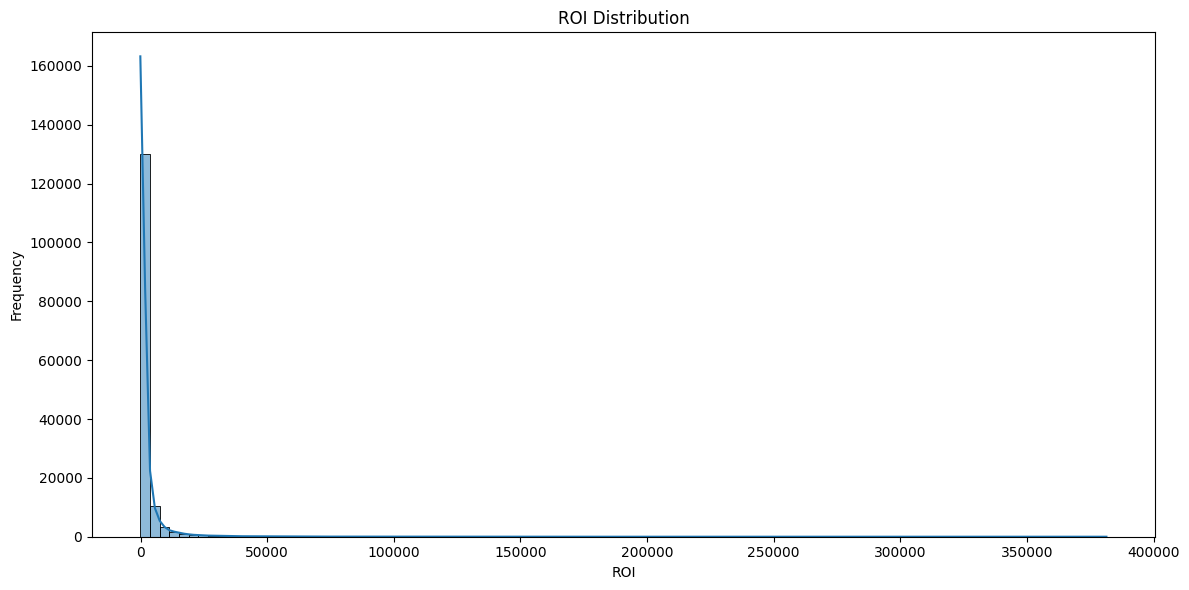

In [18]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["ROI"],
    bins=100,
    kde=True
)

plt.title("ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

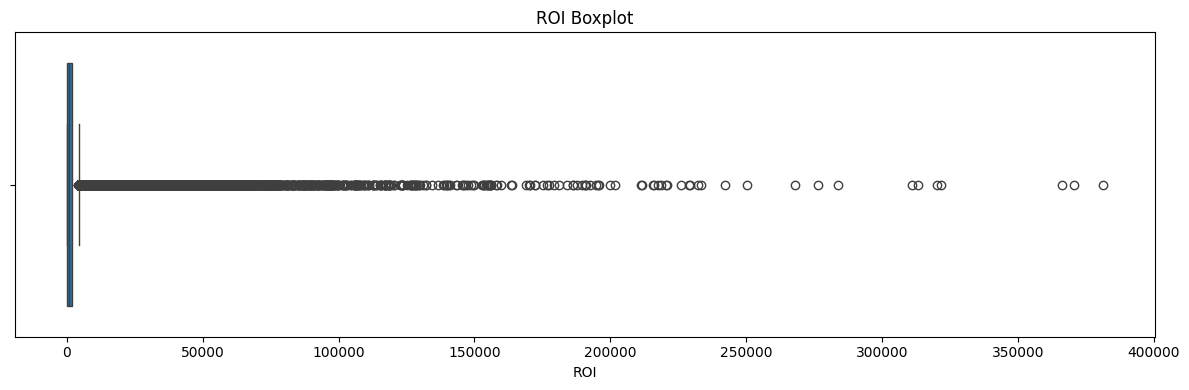

In [19]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["ROI"]
)

plt.title("ROI Boxplot")
plt.xlabel("ROI")

plt.tight_layout()
plt.show()

In [20]:
# ROI is expected to be approximately Profit / Spend * 100.
# Avoid division-by-zero warnings if any Spend value is zero.
calculated_roi = np.where(
    df["Spend"].ne(0),
    (df["Profit"] / df["Spend"]) * 100,
    np.nan
)

calculated_roi = pd.Series(calculated_roi, index=df.index)


In [21]:
roi_difference = (
    df["ROI"] - calculated_roi
).abs()

print("Maximum ROI difference:", roi_difference.max())
print("Mean ROI difference:", roi_difference.mean())
print("Rows with ROI mismatch > 0.01:", (roi_difference > 0.01).sum())


Maximum ROI difference: 0.004999965239221638
Mean ROI difference: 0.0025029254948931317
Rows with ROI mismatch > 0.01: 0


In [22]:
numerical_columns = [
    "Budget",
    "Spend",
    "Impressions",
    "Clicks",
    "CTR",
    "CPC",
    "CPM",
    "Leads",
    "Conversions",
    "ConversionRate",
    "Revenue",
    "Profit",
    "ROI",
    "Likes",
    "Shares",
    "Comments",
    "EngagementRate",
    "BounceRate",
    "SessionDuration",
    "CustomerRating",
    "CompetitorScore",
    "CampaignDurationDays",
    "RepeatCustomers",
    "NewCustomers",
    "Orders",
    "AverageOrderValue",
    "DiscountPercent",
    "RefundRate"
]

# Confirm all requested numerical columns exist before analysis.
missing_numeric_columns = [
    col for col in numerical_columns if col not in df.columns
]

if missing_numeric_columns:
    raise KeyError(f"Missing numerical columns: {missing_numeric_columns}")

df[numerical_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
Budget,150000.0,2.524603e+05,1.430918e+05,5000.5700,128081.0600,2.524475e+05,3.761816e+05,4.999961e+05
Spend,150000.0,2.208812e+05,1.269394e+05,3809.4600,111368.6575,2.192069e+05,3.270018e+05,4.984414e+05
Impressions,150000.0,1.503614e+06,8.633730e+05,10008.0000,755118.5000,1.501774e+06,2.250782e+06,2.999992e+06
Clicks,150000.0,8.253027e+04,6.534469e+04,103.0000,29401.0000,6.543400e+04,1.229608e+05,2.997400e+05
CTR,150000.0,5.492154e-02,2.600249e-02,0.0100,0.0324,5.500000e-02,7.742500e-02,1.000000e-01
CPC,150000.0,1.069256e+01,4.311125e+01,0.0200,1.3500,2.970000e+00,7.270000e+00,2.667470e+03
CPM,150000.0,4.232143e+02,1.418762e+03,1.4800,74.2475,1.462900e+02,2.919000e+02,4.007469e+04
Leads,150000.0,2.061857e+04,1.868133e+04,14.0000,6505.7500,1.494000e+04,2.928350e+04,1.153010e+05
Conversions,150000.0,8.231056e+03,8.116606e+03,5.0000,2404.0000,5.624000e+03,1.141200e+04,6.739000e+04
ConversionRate,150000.0,9.972799e-02,4.615566e-02,0.0203,0.0635,9.130000e-02,1.301000e-01,2.398000e-01


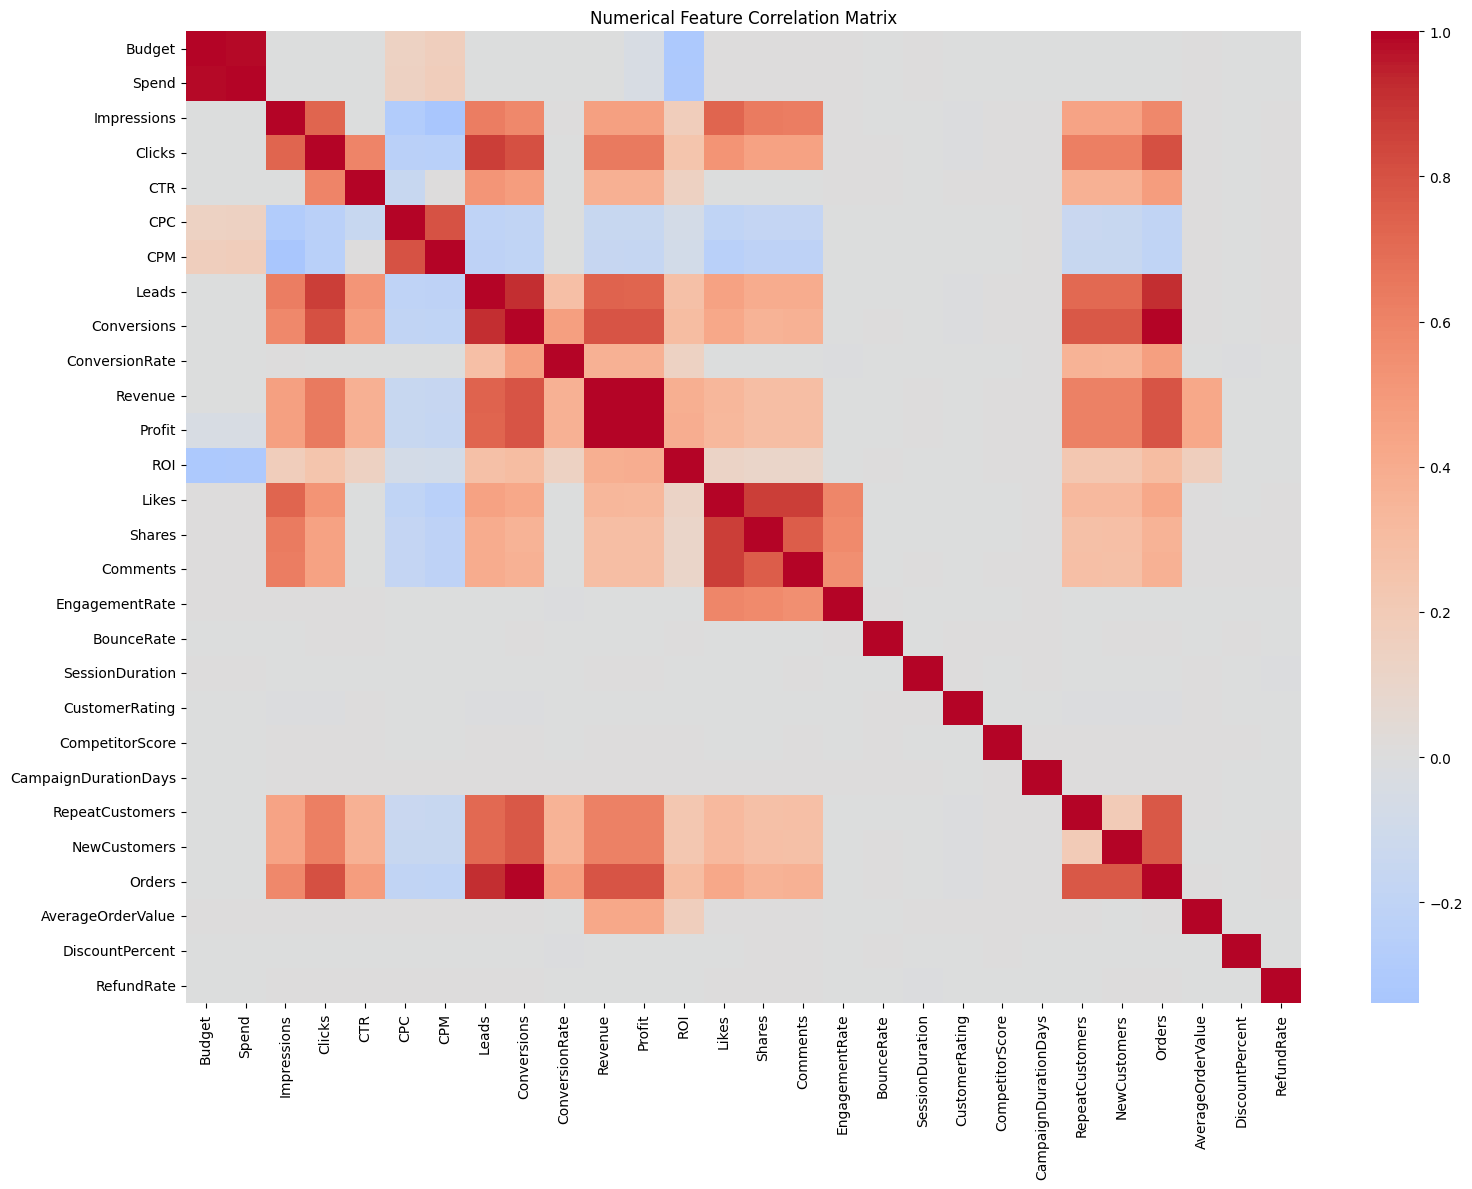

In [23]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [24]:
roi_correlation = (
    correlation["ROI"]
    .sort_values(ascending=False)
)

roi_correlation

ROI                     1.000000
Profit                  0.395973
Revenue                 0.382980
Orders                  0.303646
Conversions             0.303399
Leads                   0.278243
Clicks                  0.243443
RepeatCustomers         0.235344
NewCustomers            0.234367
Impressions             0.175773
AverageOrderValue       0.163962
CTR                     0.144911
ConversionRate          0.140944
Likes                   0.125692
Shares                  0.109529
Comments                0.109132
CampaignDurationDays    0.004964
CompetitorScore         0.004286
BounceRate              0.000926
RefundRate              0.000779
SessionDuration         0.000539
DiscountPercent        -0.002250
EngagementRate         -0.002652
CustomerRating         -0.002711
CPC                    -0.067680
CPM                    -0.077668
Spend                  -0.306591
Budget                 -0.309315
Name: ROI, dtype: float64

In [25]:
categorical_columns = [
    "Platform",
    "Region",
    "Device",
    "CustomerSegment",
    "ProductCategory",
    "CampaignType",
    "Season",
    "CampaignStatus",
    "MarketingObjective"
]

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(df[column].value_counts(dropna=False))


Platform
Platform
Facebook       21595
Google Ads     21549
Instagram      21397
LinkedIn       21386
Twitter (X)    21384
YouTube        21359
TikTok         21330
Name: count, dtype: int64

Region
Region
North America    25130
Africa           25110
South America    25101
Middle East      24919
Asia Pacific     24872
Europe           24868
Name: count, dtype: int64

Device
Device
Desktop     37673
Smart TV    37643
Tablet      37422
Mobile      37262
Name: count, dtype: int64

CustomerSegment
CustomerSegment
Student       25144
Senior        25068
Premium       24982
Enterprise    24966
New           24965
Returning     24875
Name: count, dtype: int64

ProductCategory
ProductCategory
Automobile     15165
Travel         15142
Education      15097
Electronics    15066
Beauty         15027
Finance        15017
Fashion        14894
Real Estate    14880
Healthcare     14878
Food           14834
Name: count, dtype: int64

CampaignType
CampaignType
Sales                 21605
Product Launc

In [26]:
platform_roi = (
    df.groupby("Platform")["ROI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

platform_roi

,count,mean,median
Platform,,,
Google Ads,21549,2493.907704,590.470
TikTok,21330,2468.891265,584.585
Facebook,21595,2466.679546,598.480
Instagram,21397,2417.304665,590.580
YouTube,21359,2369.984166,592.380
Twitter (X),21384,2366.317171,594.720
LinkedIn,21386,2254.446623,583.780


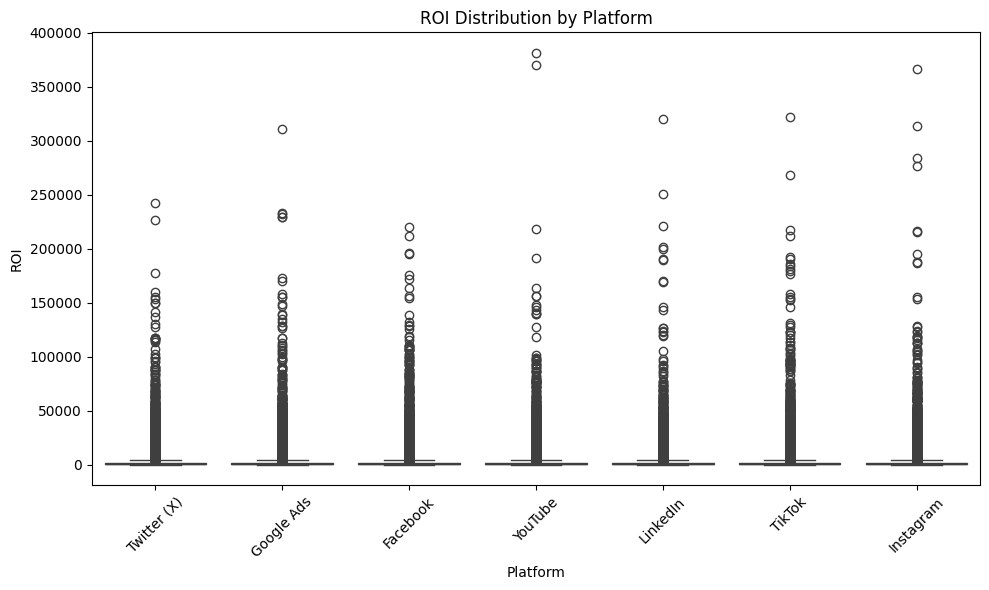

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Platform",
    y="ROI"
)

plt.title("ROI Distribution by Platform")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
campaign_type_roi = (
    df.groupby("CampaignType")["ROI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

campaign_type_roi

,count,mean,median
CampaignType,,,
App Promotion,21212,2467.372707,601.32
Seasonal Promotion,21293,2464.194012,591.06
Sales,21605,2434.090406,582.03
Retention,21510,2382.053856,592.59
Awareness,21319,2380.464228,589.51
Lead Generation,21490,2371.773589,584.24
Product Launch,21571,2339.996673,595.14


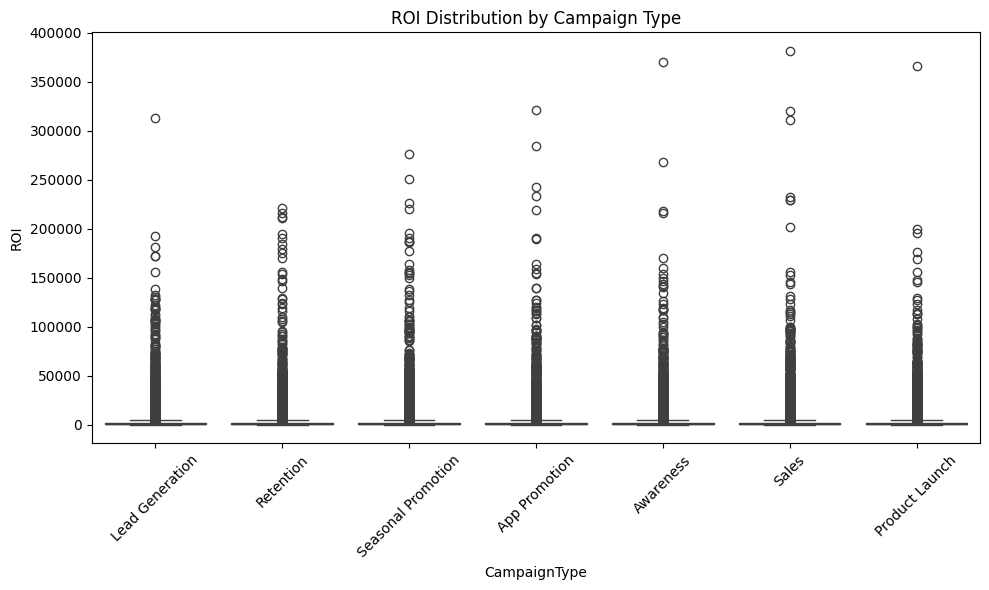

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="CampaignType",
    y="ROI"
)

plt.title("ROI Distribution by Campaign Type")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
region_roi = (
    df.groupby("Region")["ROI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

region_roi

,count,mean,median
Region,,,
Africa,25110,2482.113291,596.485
Asia Pacific,24872,2445.252135,600.800
North America,25130,2403.001645,597.290
Middle East,24919,2375.911711,586.060
South America,25101,2371.601233,583.840
Europe,24868,2354.937289,583.640


In [31]:
segment_roi = (
    df.groupby("CustomerSegment")["ROI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

segment_roi

,count,mean,median
CustomerSegment,,,
Student,25144,2426.817870,597.585
Enterprise,24966,2416.547833,580.555
Returning,24875,2406.731498,593.520
Premium,24982,2404.939797,591.475
Senior,25068,2402.396287,583.860
New,24965,2375.595045,598.670


In [32]:
objective_roi = (
    df.groupby("MarketingObjective")["ROI"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

objective_roi

,count,mean,median
MarketingObjective,,,
Lead Generation,37521,2496.267431,594.70
Brand Awareness,37765,2388.968451,596.31
Retention,37357,2381.741262,584.02
Sales Growth,37357,2354.914528,589.77


In [33]:
df["CampaignYear"] = df["CampaignDate"].dt.year
df["CampaignMonth"] = df["CampaignDate"].dt.month
df["CampaignQuarter"] = df["CampaignDate"].dt.quarter
df["CampaignDayOfWeek"] = df["CampaignDate"].dt.dayofweek

In [34]:
df[
    [
        "CampaignDate",
        "CampaignYear",
        "CampaignMonth",
        "CampaignQuarter",
        "CampaignDayOfWeek"
    ]
].head()

,CampaignDate,CampaignYear,CampaignMonth,CampaignQuarter,CampaignDayOfWeek
0,2023-08-17,2023,8,3,3
1,2023-07-29,2023,7,3,5
2,2024-03-05,2024,3,1,1
3,2023-10-20,2023,10,4,4
4,2024-11-27,2024,11,4,2


In [35]:
yearly_roi = (
    df.groupby("CampaignYear")["ROI"]
    .agg(["count", "mean", "median"])
)

yearly_roi

,count,mean,median
CampaignYear,,,
2023,50025,2381.928656,582.080
2024,50225,2425.047337,584.500
2025,49750,2409.549963,603.935


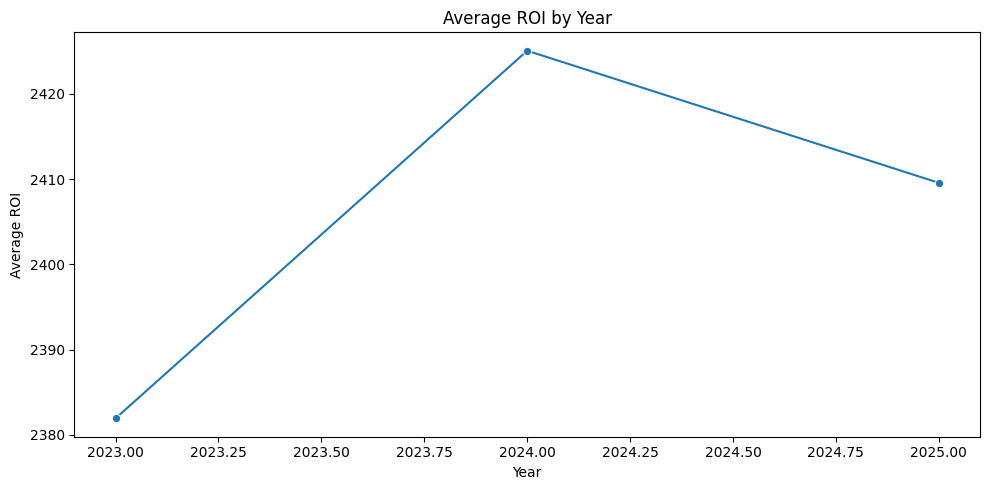

In [36]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_roi,
    x=yearly_roi.index,
    y="mean",
    marker="o"
)

plt.title("Average ROI by Year")
plt.xlabel("Year")
plt.ylabel("Average ROI")

plt.tight_layout()
plt.show()

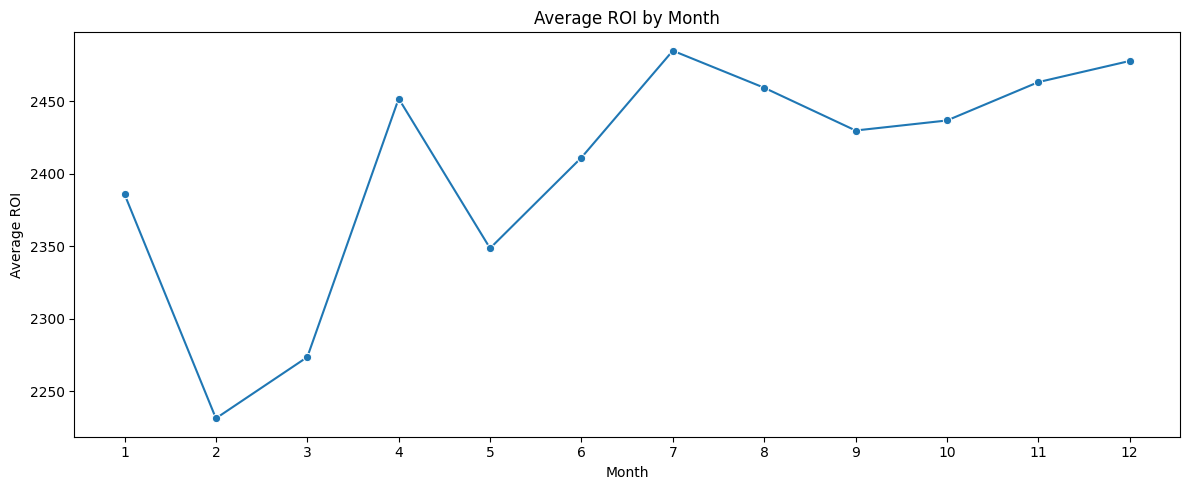

In [37]:
monthly_roi = (
    df.groupby("CampaignMonth")["ROI"]
    .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=monthly_roi.index,
    y=monthly_roi.values,
    marker="o"
)

plt.title("Average ROI by Month")
plt.xlabel("Month")
plt.ylabel("Average ROI")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

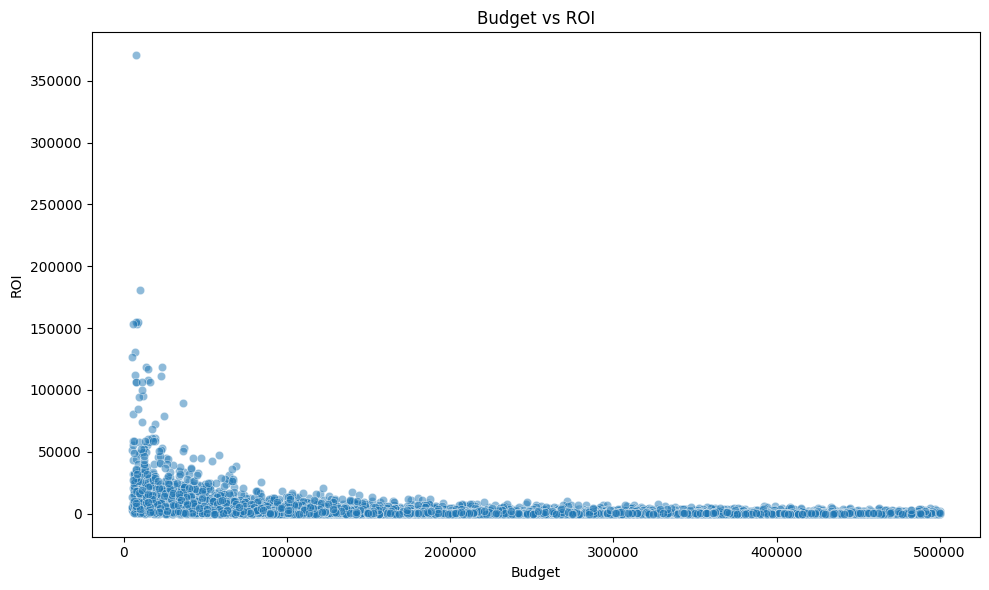

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Budget",
    y="ROI",
    alpha=0.5
)

plt.title("Budget vs ROI")
plt.xlabel("Budget")
plt.ylabel("ROI")

plt.tight_layout()
plt.show()

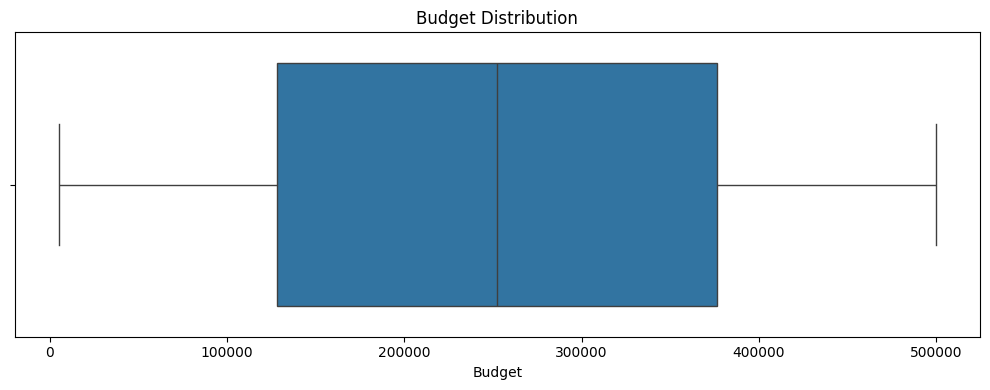

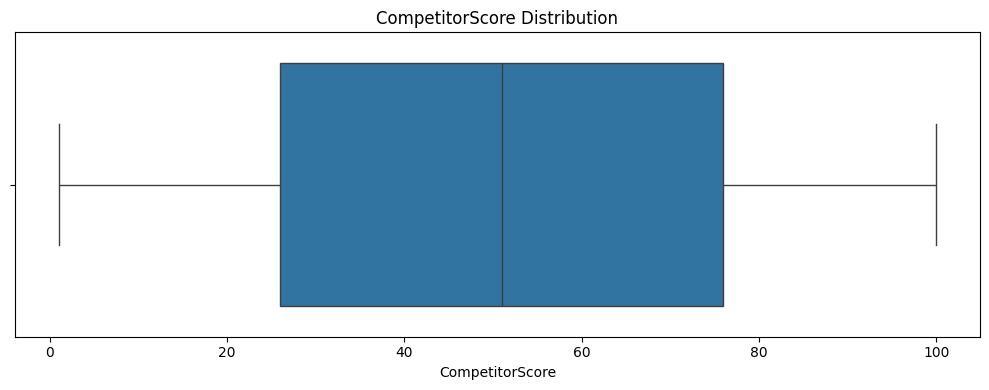

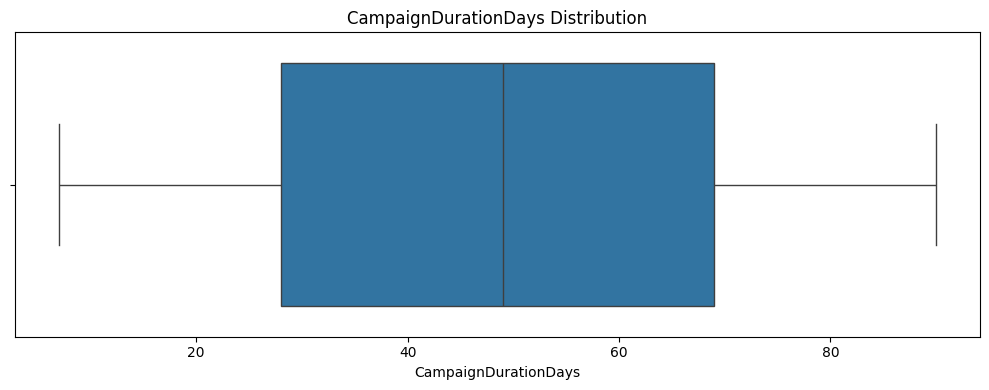

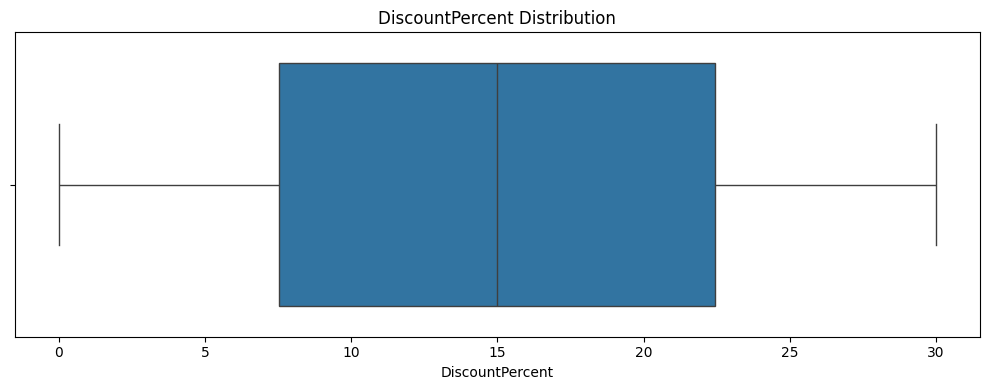

In [39]:
production_numeric = [
    "Budget",
    "CompetitorScore",
    "CampaignDurationDays",
    "DiscountPercent"
]

for column in production_numeric:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"{column} Distribution")

    plt.tight_layout()
    plt.show()

In [40]:
FINAL_NUMERICAL_FEATURES = [
    "Budget",
    "CompetitorScore",
    "CampaignDurationDays",
    "DiscountPercent"
]

FINAL_CATEGORICAL_FEATURES = [
    "Platform",
    "Region",
    "Device",
    "CustomerSegment",
    "ProductCategory",
    "CampaignType",
    "Season",
    "MarketingObjective"
]

FINAL_DATE_FEATURES = [
    "CampaignYear",
    "CampaignMonth",
    "CampaignQuarter",
    "CampaignDayOfWeek"
]

TARGET = "ROI"


In [41]:
ML_COLUMNS = (
    FINAL_NUMERICAL_FEATURES
    + FINAL_CATEGORICAL_FEATURES
    + FINAL_DATE_FEATURES
    + [TARGET]
)

missing_ml_columns = [col for col in ML_COLUMNS if col not in df.columns]

if missing_ml_columns:
    raise KeyError(f"Missing ML columns: {missing_ml_columns}")

ml_df = df[ML_COLUMNS].copy()

print("ML dataset shape:", ml_df.shape)
display(ml_df.head())


ML dataset shape: (150000, 17)


,Budget,CompetitorScore,CampaignDurationDays,DiscountPercent,Platform,Region,Device,CustomerSegment,ProductCategory,CampaignType,Season,MarketingObjective,CampaignYear,CampaignMonth,CampaignQuarter,CampaignDayOfWeek,ROI
0,17380.32,54,35,17.68,Twitter (X),Europe,Smart TV,Premium,Education,Lead Generation,Spring,Sales Growth,2023,8,3,3,2450.76
1,50909.19,85,36,8.68,Google Ads,Middle East,Tablet,Enterprise,Automobile,Lead Generation,Summer,Sales Growth,2023,7,3,5,10672.08
2,336736.71,8,36,0.96,Facebook,South America,Tablet,Returning,Travel,Retention,Holiday,Retention,2024,3,1,1,1871.70
3,136115.68,88,61,1.91,YouTube,Asia Pacific,Desktop,Senior,Fashion,Seasonal Promotion,Festival,Sales Growth,2023,10,4,4,4506.06
4,60218.33,21,76,27.55,Google Ads,Asia Pacific,Tablet,Returning,Electronics,Lead Generation,Festival,Brand Awareness,2024,11,4,2,3098.27


In [42]:
print("Missing values:")
print(ml_df.isnull().sum())

print("\nShape:")
print(ml_df.shape)

print("\nData types:")
print(ml_df.dtypes)

Missing values:
Budget                  0
CompetitorScore         0
CampaignDurationDays    0
DiscountPercent         0
Platform                0
Region                  0
Device                  0
CustomerSegment         0
ProductCategory         0
CampaignType            0
Season                  0
MarketingObjective      0
CampaignYear            0
CampaignMonth           0
CampaignQuarter         0
CampaignDayOfWeek       0
ROI                     0
dtype: int64

Shape:
(150000, 17)

Data types:
Budget                  float64
CompetitorScore           int64
CampaignDurationDays      int64
DiscountPercent         float64
Platform                 object
Region                   object
Device                   object
CustomerSegment          object
ProductCategory          object
CampaignType             object
Season                   object
MarketingObjective       object
CampaignYear              int32
CampaignMonth             int32
CampaignQuarter           int32
CampaignDayOfWe

In [43]:
print(
    "ROI missing:",
    ml_df["ROI"].isnull().sum()
)

print(
    "ROI infinite:",
    np.isinf(ml_df["ROI"]).sum()
)

ROI missing: 0
ROI infinite: 0


In [44]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

output_file = processed_dir / "campaign_roi_ml_dataset.csv"

ml_df.to_csv(
    output_file,
    index=False
)

print("Processed ML dataset saved successfully:")
print(output_file)
print("Shape:", ml_df.shape)


Processed ML dataset saved successfully:
C:\Users\Manas K. Bhoir\Desktop\campaign-roi-estimation\data\processed\campaign_roi_ml_dataset.csv
Shape: (150000, 17)


In [45]:
print("ROI Statistics")
print("=" * 50)

print(df["ROI"].describe())

print("\nPercentiles")
print("=" * 50)

print(
    df["ROI"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

ROI Statistics
count    150000.000000
mean       2405.527294
std        8212.914501
min         -99.870000
25%         127.725000
50%         590.800000
75%        1839.552500
max      381367.740000
Name: ROI, dtype: float64

Percentiles
0.01      -91.5301
0.05      -63.2910
0.25      127.7250
0.50      590.8000
0.75     1839.5525
0.95     9147.8270
0.99    32372.8353
Name: ROI, dtype: float64


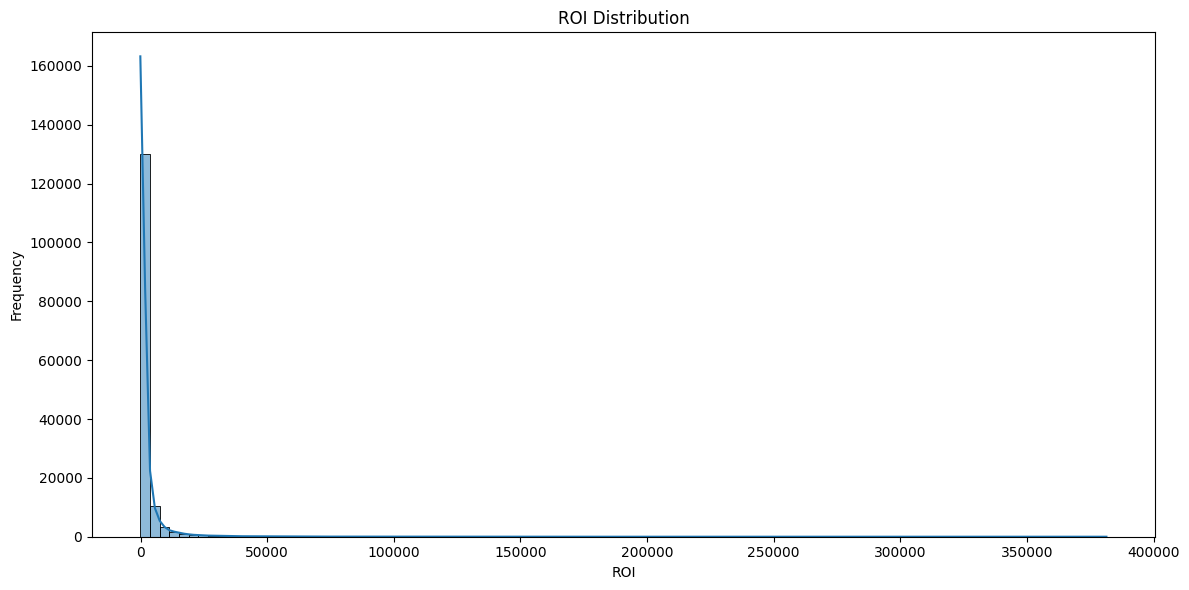

In [46]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["ROI"],
    bins=100,
    kde=True
)

plt.title("ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [47]:
print(
    "ROI < 0:",
    (df["ROI"] < 0).sum()
)

print(
    "ROI > 1000:",
    (df["ROI"] > 1000).sum()
)

print(
    "ROI > 5000:",
    (df["ROI"] > 5000).sum()
)

ROI < 0: 19272
ROI > 1000: 57449
ROI > 5000: 14514
